In [64]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


In [125]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier

In [66]:
df = pd.read_csv("/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [67]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [68]:
df.shape

(284807, 31)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

<Axes: xlabel='Class'>

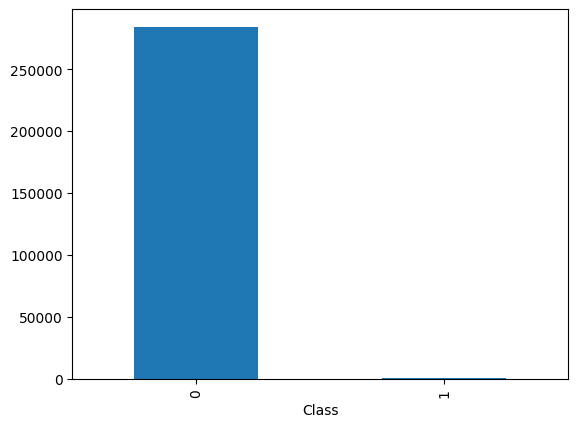

In [70]:
df["Class"].value_counts().plot(kind="bar")

In [71]:
print("missing values:\n",df.isnull().sum())
print("duplicate values:\n", df.duplicated().sum())

missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
duplicate values:
 1081


In [72]:
df[df.duplicated()]['Class'].value_counts()

Class
0    1062
1      19
Name: count, dtype: int64

In [73]:
df[df.duplicated(keep=False) & (df["Class"] == 1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102441,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141257,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141259,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1


In [74]:
df.groupby('Class')["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


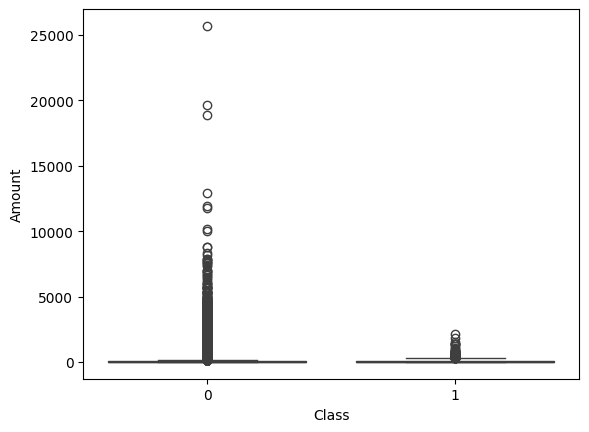

In [75]:
sns.boxplot(data=df, x="Class", y="Amount")
plt.show()

In [76]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


In [77]:
corr = df.corr(numeric_only=True)["Class"].sort_values()

corr

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

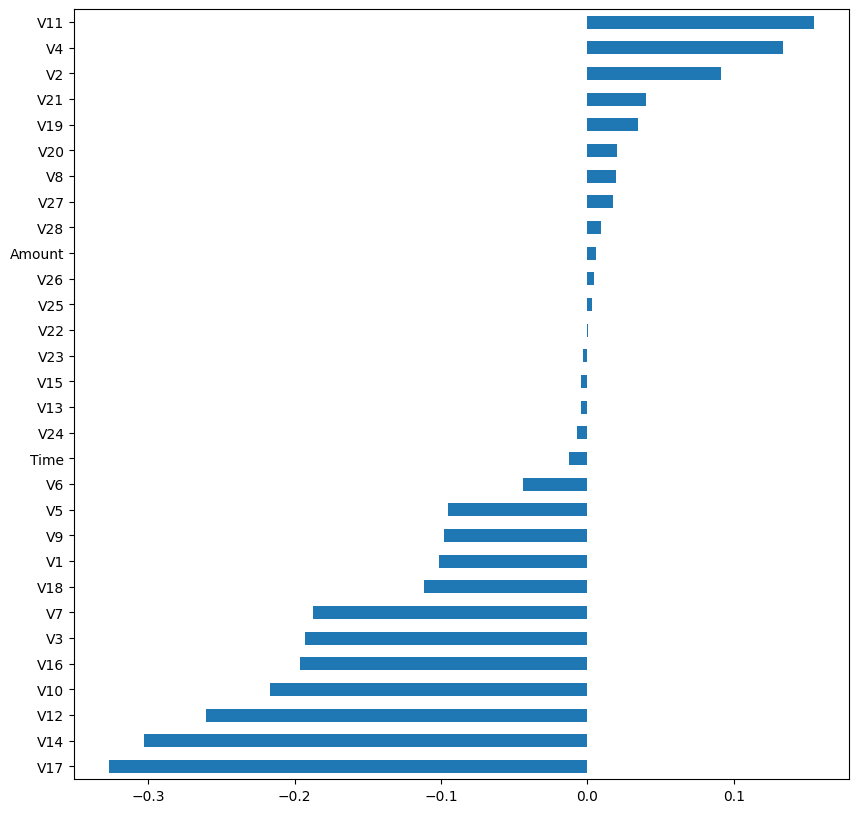

In [78]:
corr.drop("Class").sort_values().plot(kind="barh", figsize=(10, 10))
plt.show()

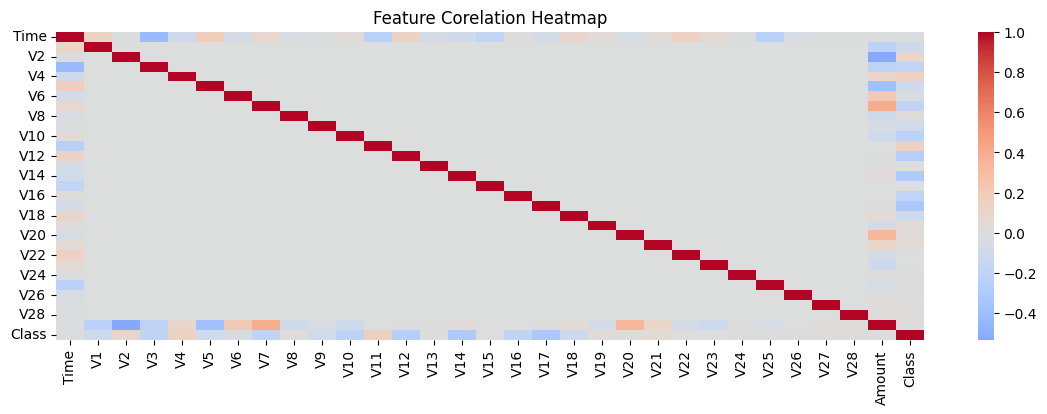

In [79]:
plt.figure(figsize=(14, 4))
sns.heatmap(
    df.corr(),cmap="coolwarm",center=0
)
plt.title("Feature Corelation Heatmap")
plt.show()

In [80]:
X = df.drop('Class',axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

In [81]:
print("Train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Train:
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Test:
Class
0    56864
1       98
Name: count, dtype: int64
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [82]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [84]:
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = model.predict(X_test_scaled)

In [85]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_test_pred)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.9755275446789088

In [86]:
cm = confusion_matrix(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
pr_auc = average_precision_score(y_test, y_test_prob)

print(cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("PR-AUC:", pr_auc)

[[55478  1386]
 [    8    90]]
Precision: 0.06097560975609756
Recall: 0.9183673469387755
F1: 0.11435832274459974
PR-AUC: 0.7189705771419241


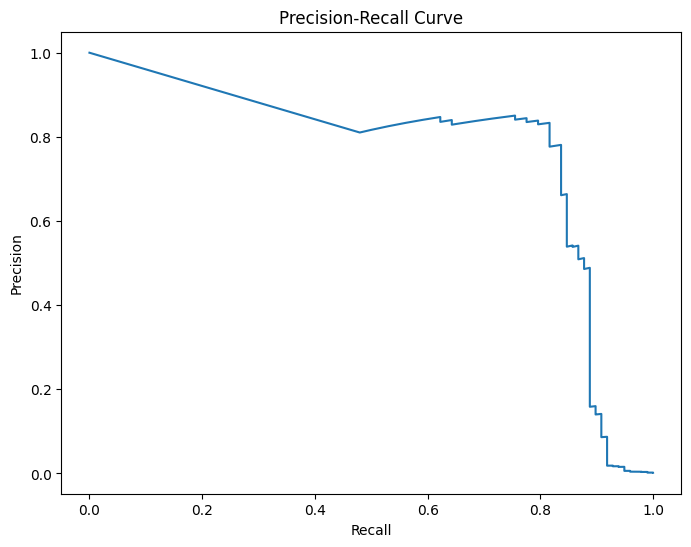

In [89]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [92]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df.head()

,threshold,precision,recall
0,3.709210e-31,0.001720,1.0
1,6.012686e-25,0.001720,1.0
2,6.195339e-25,0.001721,1.0
3,4.118397e-23,0.001721,1.0
4,7.616379e-22,0.001721,1.0


In [93]:
target_recall = 0.80

valid = threshold_df[threshold_df["recall"] >= target_recall]

best = valid.loc[valid["precision"].idxmax()]

print(best)

threshold    1.000000
precision    0.833333
recall       0.816327
Name: 56797, dtype: float64


In [95]:
best_threshold = best["threshold"]

y_test_pred_tuned = (
    y_test_prob >= best_threshold
).astype(int)

cm = confusion_matrix(y_test, y_test_pred_tuned)

print(cm)

[[56848    16]
 [   18    80]]


In [96]:
precision = precision_score(y_test, y_test_pred_tuned)
recall = recall_score(y_test, y_test_pred_tuned)
f1 = f1_score(y_test, y_test_pred_tuned)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8333333333333334
Recall: 0.8163265306122449
F1 Score: 0.8247422680412371


In [99]:
roc_auc = roc_auc_score(y_test, y_test_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9720834996210077


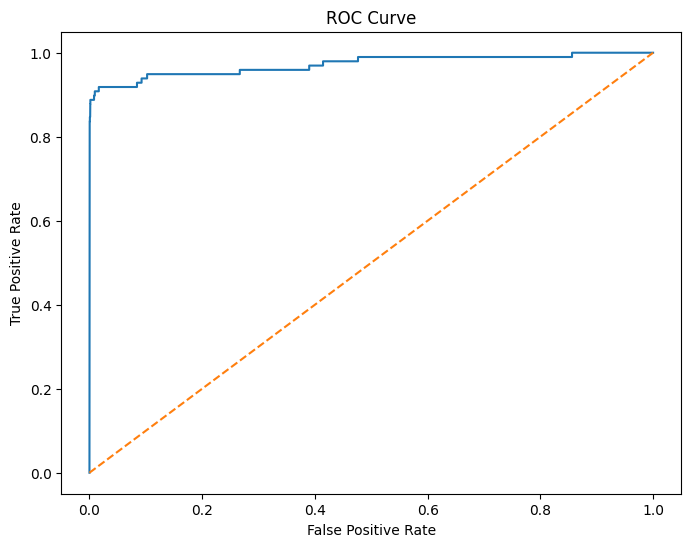

In [103]:
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.show()

In [104]:
roc_auc = roc_auc_score(y_test, y_test_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9720834996210077


In [106]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [107]:
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]
y_rf_pred = (y_rf_prob >= 0.5).astype(int)

In [108]:
print("Precision:", precision_score(y_test, y_rf_pred))
print("Recall:", recall_score(y_test, y_rf_pred))
print("F1 Score:", f1_score(y_test, y_rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_rf_prob))
print("PR-AUC / AP:", average_precision_score(y_test, y_rf_prob))
print(confusion_matrix(y_test, y_rf_pred))

Precision: 0.961038961038961
Recall: 0.7551020408163265
F1 Score: 0.8457142857142858
ROC-AUC: 0.9571890288895525
PR-AUC / AP: 0.8589278575500874
[[56861     3]
 [   24    74]]


In [109]:
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(
    y_test,
    y_rf_prob0
)

rf_threshold_df = pd.DataFrame({
    "threshold": rf_thresholds,
    "precision": rf_precision[:-1],
    "recall": rf_recall[:-1]
})

rf_threshold_df.head()

,threshold,precision,recall
0,0.000,0.001720,1.000000
1,0.005,0.042076,0.918367
2,0.010,0.130952,0.897959
3,0.015,0.232190,0.897959
4,0.020,0.337165,0.897959


In [110]:
target_recall = 0.80

valid_rf = rf_threshold_df[
    rf_threshold_df["recall"] >= target_recall
]

best_rf = valid_rf.loc[
    valid_rf["precision"].idxmax()
]

print(best_rf)

threshold    0.330000
precision    0.952941
recall       0.826531
Name: 41, dtype: float64


In [113]:
best_rf_threshold = best_rf["threshold"]

y_rf_pred_tuned = (
    y_rf_prob >= best_rf_threshold
).astype(int)

print(confusion_matrix(y_test, y_rf_pred_tuned))

print("Precision:", precision_score(y_test, y_rf_pred_tuned))
print("Recall:", recall_score(y_test, y_rf_pred_tuned))
print("F1 Score:", f1_score(y_test, y_rf_pred_tuned))

[[56860     4]
 [   17    81]]
Precision: 0.9529411764705882
Recall: 0.826530612244898
F1 Score: 0.8852459016393442


In [114]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [117]:
y_val_prob = rf_model.predict_proba(X_val)[:, 1]
val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

val_threshold_df = pd.DataFrame({
    "threshold": val_thresholds,
    "precision": val_precision[:-1],
    "recall": val_recall[:-1]
})

val_threshold_df.head()

,threshold,precision,recall
0,0.000,0.001734,1.0
1,0.005,0.097052,1.0
2,0.010,0.351111,1.0
3,0.015,0.617188,1.0
4,0.020,0.686957,1.0


In [118]:
target_recall = 0.80

valid_val = val_threshold_df[
    val_threshold_df["recall"] >= target_recall
]

best_val = valid_val.loc[
    valid_val["precision"].idxmax()
]

print(best_val)

threshold    0.595
precision    1.000
recall       1.000
Name: 21, dtype: float64


In [121]:
final_threshold = best_val["threshold"]

y_test_final_prob = rf_model.predict_proba(X_test)[:, 1]

y_test_final_pred = (
    y_test_final_prob >= final_threshold
).astype(int)

print(confusion_matrix(y_test, y_test_final_pred))
print("Precision:", precision_score(y_test, y_test_final_pred))
print("Recall:", recall_score(y_test, y_test_final_pred))
print("F1 Score:", f1_score(y_test, y_test_final_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_final_prob))
print("PR-AUC / AP:", average_precision_score(y_test, y_test_final_prob))

[[56862     2]
 [   27    71]]
Precision: 0.9726027397260274
Recall: 0.7244897959183674
F1 Score: 0.8304093567251462
ROC-AUC: 0.9571890288895525
PR-AUC / AP: 0.8589278575500874


In [123]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(15))

   feature  importance
14     V14    0.172755
4       V4    0.115382
10     V10    0.111231
12     V12    0.093417
17     V17    0.092719
3       V3    0.064234
11     V11    0.058795
16     V16    0.051311
2       V2    0.028824
7       V7    0.025840
9       V9    0.019088
21     V21    0.018189
19     V19    0.012253
29  Amount    0.011777
20     V20    0.011611


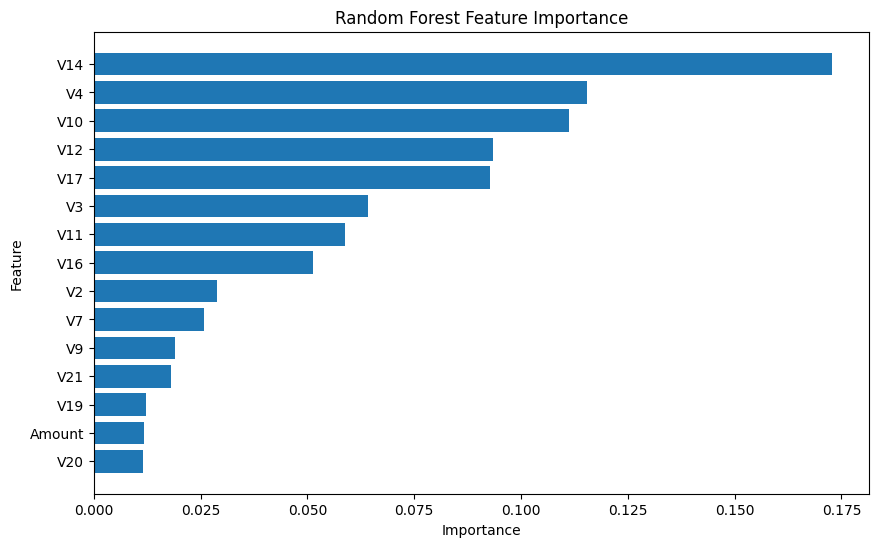

In [124]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"].head(15)[::-1],
    feature_importance["importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=5,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train_model, y_train_model)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, 15, 20],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 150, 200]},
                   random_state=42, scoring='average_precision', verbose=2)

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 3.8min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 3.7min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.8min


In [129]:
print("Best Parameters:")
print(rf_search.best_params_)

print("Best CV PR-AUC:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Best CV PR-AUC:
0.8352015778263623


In [130]:
best_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(X_train_model, y_train_model)

y_val_prob = best_rf_model.predict_proba(X_val)[:, 1]

[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 3.7min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 2.7min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 2.0min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 2.3min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 2.9min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 2.7min
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 3.7min
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 1.9min
[CV] END max_depth=20, max_features=sqrt

In [131]:
val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

val_threshold_df = pd.DataFrame({
    "threshold": val_thresholds,
    "precision": val_precision[:-1],
    "recall": val_recall[:-1]
})

target_recall = 0.80

valid_val = val_threshold_df[
    val_threshold_df["recall"] >= target_recall
]

best_val = valid_val.loc[
    valid_val["precision"].idxmax()
]

print(best_val)

threshold    0.119840
precision    0.800000
recall       0.810127
Name: 805, dtype: float64


In [133]:
final_threshold = best_val["threshold"]

y_test_final_prob = best_rf_model.predict_proba(X_test)[:, 1]

y_test_final_pred = (
    y_test_final_prob >= final_threshold
).astype(int)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_final_pred))

print("Precision:", precision_score(y_test, y_test_final_pred))
print("Recall:", recall_score(y_test, y_test_final_pred))
print("F1 Score:", f1_score(y_test, y_test_final_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_final_prob))
print("PR-AUC / AP:", average_precision_score(y_test, y_test_final_prob))

Confusion Matrix:
[[56825    39]
 [   11    87]]
Precision: 0.6904761904761905
Recall: 0.8877551020408163
F1 Score: 0.7767857142857143
ROC-AUC: 0.9666748733821048
PR-AUC / AP: 0.8582925961762005


In [134]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Random Forest"
    ],
    "Precision": [
        0.060976,
        0.690476
    ],
    "Recall": [
        0.918367,
        0.887755
    ],
    "F1 Score": [
        0.114358, 
        0.776786
    ],
    "ROC-AUC": [
        None,          # Logistic ROC-AUC ka exact value humne save nahi kiya tha
        0.966675
    ],
    "PR-AUC / AP": [
        0.718971,
        0.858293
    ]
})

print(comparison)

                 Model  Precision    Recall  F1 Score   ROC-AUC  PR-AUC / AP
0  Logistic Regression   0.060976  0.918367  0.114358       NaN     0.718971
1  Tuned Random Forest   0.690476  0.887755  0.776786  0.966675     0.858293
